# First Name:  Elijah
# Last Name: Ang

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.stats.multicomp as multi 
import matplotlib.pyplot as plt

# From Prac 1 to 3

In [3]:
nesarc = pd.read_csv('nesarc.csv', low_memory=False)
pd.set_option('display.float_format', lambda x:'%f'%x)

In [4]:
nesarc['S2AQ5B'] = pd.to_numeric(nesarc['S2AQ5B'], errors='coerce') #convert variable to numeric
nesarc['S2AQ5D'] = pd.to_numeric(nesarc['S2AQ5D'], errors='coerce') #convert variable to numeric
nesarc['S2AQ5A'] = pd.to_numeric(nesarc['S2AQ5A'], errors='coerce') #convert variable to numeric

In [5]:
sub1=nesarc[(nesarc['AGE']>=26) & (nesarc['AGE']<=50) & (nesarc['S2AQ5A']==1)]
sub2=sub1.copy()

In [6]:
#SETTING MISSING DATA
sub2['S2AQ5D']=sub2['S2AQ5D'].replace(99, np.nan)

sub2['S2AQ5B']=sub2['S2AQ5B'].replace(8, np.nan)
sub2['S2AQ5B']=sub2['S2AQ5B'].replace(9, np.nan)
sub2['S2AQ5B']=sub2['S2AQ5B'].replace(10, np.nan)
sub2['S2AQ5B']=sub2['S2AQ5B'].replace(99, np.nan)

In [7]:
recode2 = {1:30, 2:26, 3:14, 4:8, 5:4, 6:2.5, 7:1}
sub2['BEER_FEQMO']= sub2['S2AQ5B'].map(recode2)
sub2['BEER_FEQMO']= pd.to_numeric(sub2['BEER_FEQMO'])

In [8]:
# Creating a secondary variable multiplying the days consumed beer/month and the number of beer/per day
sub2['NUMBEERMO_EST']=sub2['BEER_FEQMO'] * sub2['S2AQ5D']
sub2['NUMBEERMO_EST']= pd.to_numeric(sub2['NUMBEERMO_EST'])

In [9]:
ct1 = sub2.groupby('NUMBEERMO_EST').size()
print (ct1)

NUMBEERMO_EST
1.000000      477
2.000000      407
2.500000      414
3.000000      172
4.000000      429
             ... 
520.000000      1
540.000000      2
624.000000      1
720.000000      2
900.000000      1
Length: 75, dtype: int64


# Categorical -> Quantitative - ANOVA

In [10]:
sub2['DYSLIFE'] = sub2['DYSLIFE'].astype('category') 

# Draw boxplot to show relationship between minor depression status (DYSLIFE (categorical)) and estimated number of beer consumed (NUMBEERMO_EST (quantitative))

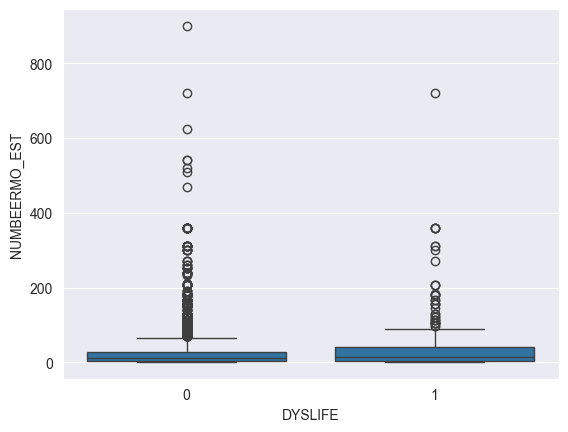

In [12]:
fig = plt.figure()
sns.boxplot(x='DYSLIFE', y='NUMBEERMO_EST', data=sub2)
plt.xlabel('DYSLIFE')
plt.ylabel('NUMBEERMO_EST')
plt.show()

# Perform ANOVA analysis between minor depression status (DYSLIFE (categorical)) and estimated number of beer consumed (NUMBEERMO_EST (quantitative))

In [13]:
model1 = smf.ols('NUMBEERMO_EST ~ C(DYSLIFE)', data=sub2).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          NUMBEERMO_EST   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     20.23
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           6.99e-06
Time:                        17:38:12   Log-Likelihood:                -38804.
No. Observations:                7303   AIC:                         7.761e+04
Df Residuals:                    7301   BIC:                         7.763e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          27.2277      0.587     

In [14]:
sub3 = sub2[['NUMBEERMO_EST', 'DYSLIFE']].dropna()

# print the mean of number of beer consumed grouped by minor depression status (use sub3)

In [15]:
print ('means for NUMBEERMO_EST by minor depression status')
m1 = sub3.groupby('DYSLIFE')['NUMBEERMO_EST'].mean()
print(m1)

means for NUMBEERMO_EST by minor depression status
DYSLIFE
0   27.227714
1   40.194719
Name: NUMBEERMO_EST, dtype: float64


/var/folders/m_/5hjxnlm94j53h6kj050rk1300000gn/T/ipykernel_47651/3226467452.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m1 = sub3.groupby('DYSLIFE')['NUMBEERMO_EST'].mean()


# print the standard deviation (std) of number beer consumed grouped by minor depression status (use sub3)

In [16]:
print ('standard deviations for NUMBEERMO_EST by minor depression status')
sd1 = sub3.groupby('DYSLIFE')['NUMBEERMO_EST'].std()
print(sd1)

standard deviations for NUMBEERMO_EST by minor depression status
DYSLIFE
0   47.678467
1   75.407118
Name: NUMBEERMO_EST, dtype: float64


/var/folders/m_/5hjxnlm94j53h6kj050rk1300000gn/T/ipykernel_47651/2949943.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sd1 = sub3.groupby('DYSLIFE')['NUMBEERMO_EST'].std()


# Categorical (>2) -> Quantitative - ANOVA

In [ ]:
sub2['ETHRACE2A'] = sub2['ETHRACE2A'].astype('category') 
sub2['ETHRACE2A']=sub2['ETHRACE2A'].cat.rename_categories(["White", "Black", "NatAm", "Asian", "Hispanic"])

# Draw boxplot to show relationship between ethinicity (ETHRACE2A (categorical)) and estimated number of beer consumed (NUMBEERMO_EST (quantitative))

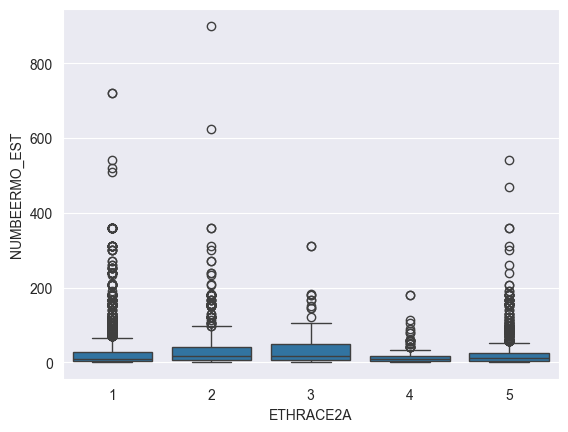

In [17]:
fig = plt.figure()
sns.boxplot(x='ETHRACE2A', y='NUMBEERMO_EST', data=sub2)
plt.xlabel('ETHRACE2A')
plt.ylabel('NUMBEERMO_EST')
plt.show()

In [19]:
sub4 = sub2[['NUMBEERMO_EST', 'ETHRACE2A']].dropna()

# Perform ANOVA analysis between ethinicity (ETHRACE2A (categorical)) and estimated number of beer consumed (NUMBEERMO_EST (quantitative))

In [20]:
model2 = smf.ols('NUMBEERMO_EST ~ C(ETHRACE2A)', data=sub4).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:          NUMBEERMO_EST   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     8.261
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.21e-06
Time:                        17:40:30   Log-Likelihood:                -38797.
No. Observations:                7303   AIC:                         7.760e+04
Df Residuals:                    7298   BIC:                         7.764e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            27.8589      0.74

# print the mean of number of beer consumed grouped by ethinicity

In [21]:
print ('means for NUMBEERMO_EST by ethinicity')
m2 = sub4.groupby('ETHRACE2A')['NUMBEERMO_EST'].mean()
print(m2)

means for NUMBEERMO_EST by ethinicity
ETHRACE2A
1   27.858922
2   32.443182
3   39.508475
4   16.600000
5   24.618638
Name: NUMBEERMO_EST, dtype: float64


# print the standard deviation (std) of number of beer consumed grouped by ethinicity

In [22]:
print ('standard deviations for NUMBEERMO_EST  by ethnicity')
sd2 = sub4.groupby('ETHRACE2A')['NUMBEERMO_EST'].std()
print(sd2)

standard deviations for NUMBEERMO_EST  by ethnicity
ETHRACE2A
1   50.537013
2   55.289755
3   57.231386
4   25.572698
5   41.073842
Name: NUMBEERMO_EST, dtype: float64


# Perform Tukey’s Honestly Significant Difference (Post hoc) test 

In [23]:
mc1 = multi.MultiComparison(sub4['NUMBEERMO_EST'], sub4['ETHRACE2A'])
res1 = mc1.tukeyhsd()
print(res1.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2   4.5843 0.0448   0.0655   9.103   True
     1      3  11.6496 0.0815  -0.8492 24.1483  False
     1      4 -11.2589  0.015 -21.0646 -1.4532   True
     1      5  -3.2403  0.175  -7.2359  0.7553  False
     2      3   7.0653 0.5721   -5.913 20.0436  False
     2      4 -15.8432 0.0003 -26.2532 -5.4331   True
     2      5  -7.8245 0.0006 -13.1332 -2.5159   True
     3      4 -22.9085 0.0006 -38.5344 -7.2826   True
     3      5 -14.8898 0.0132 -27.6954 -2.0843   True
     4      5   8.0186 0.2007  -2.1752 18.2125  False
-----------------------------------------------------
